# Regresión lineal aplicada a la concentración de CO en Nueva York (2022)

Este cuaderno analiza la concentración máxima diaria de monóxido de carbono (CO) registrada en estaciones del estado de Nueva York durante 2022.

**Variable analizada:** `Daily Max 8-hour CO Concentration`  
**Unidad:** partes por millón (ppm)  
**Objetivo:** construir y evaluar modelos de regresión lineal que permitan explicar la variación diaria del CO mediante tendencia temporal, estacionalidad, fin de semana y concentración del día anterior.

> El AQI se utiliza solamente en el análisis exploratorio. No se incorpora como predictor porque se calcula a partir de la concentración del contaminante y generaría redundancia.

## 1. Importación de librerías

Se importan las herramientas necesarias para manipular datos, construir los modelos, calcular métricas y elaborar los gráficos.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

## 2. Carga de datos



In [2]:
RUTA = "/content/Data1_CO_New York.csv"
CONC = "Daily Max 8-hour CO Concentration"

if not os.path.exists(RUTA):
    raise FileNotFoundError(
    )

df = pd.read_csv(RUTA)
df.columns = df.columns.str.strip()

print("Archivo cargado correctamente")
print("Filas y columnas:", df.shape)
df.head()

Archivo cargado correctamente
Filas y columnas: (3596, 21)


,Date,Source,Site ID,POC,Daily Max 8-hour CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,360050133,1,0.4,ppm,5,PFIZER LAB SITE,19,79.0,42101,Carbon monoxide,593,35620,"New York-Newark-Jersey City, NY-NJ-PA",36,New York,5,Bronx,40.8679,-73.87809
1,01/02/2022,AQS,360050133,1,0.4,ppm,5,PFIZER LAB SITE,24,100.0,42101,Carbon monoxide,593,35620,"New York-Newark-Jersey City, NY-NJ-PA",36,New York,5,Bronx,40.8679,-73.87809
2,01/03/2022,AQS,360050133,1,0.4,ppm,5,PFIZER LAB SITE,24,100.0,42101,Carbon monoxide,593,35620,"New York-Newark-Jersey City, NY-NJ-PA",36,New York,5,Bronx,40.8679,-73.87809
3,01/04/2022,AQS,360050133,1,0.4,ppm,5,PFIZER LAB SITE,17,71.0,42101,Carbon monoxide,593,35620,"New York-Newark-Jersey City, NY-NJ-PA",36,New York,5,Bronx,40.8679,-73.87809
4,01/05/2022,AQS,360050133,1,0.5,ppm,6,PFIZER LAB SITE,24,100.0,42101,Carbon monoxide,593,35620,"New York-Newark-Jersey City, NY-NJ-PA",36,New York,5,Bronx,40.8679,-73.87809


### 2.1 Revisión inicial

`info()` permite verificar los tipos de datos y la cantidad de valores presentes. La expresión `non-null` significa que la celda contiene información.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3596 entries, 0 to 3595
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               3596 non-null   object 
 1   Source                             3596 non-null   object 
 2   Site ID                            3596 non-null   int64  
 3   POC                                3596 non-null   int64  
 4   Daily Max 8-hour CO Concentration  3596 non-null   float64
 5   Units                              3596 non-null   object 
 6   Daily AQI Value                    3596 non-null   int64  
 7   Local Site Name                    3596 non-null   object 
 8   Daily Obs Count                    3596 non-null   int64  
 9   Percent Complete                   3596 non-null   float64
 10  AQS Parameter Code                 3596 non-null   int64  
 11  AQS Parameter Description          3596 non-null   objec

In [4]:
print("Valores faltantes en las variables principales:")
display(df[["Date", CONC, "Daily AQI Value", "Local Site Name", "County"]].isnull().sum())

print("\nResumen estadístico:")
display(df[[CONC, "Daily AQI Value", "Daily Obs Count", "Percent Complete"]].describe().round(4))

Valores faltantes en las variables principales:


,0
Date,0
Daily Max 8-hour CO Concentration,0
Daily AQI Value,0
Local Site Name,0
County,0



Resumen estadístico:


,Daily Max 8-hour CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete
count,3596.0000,3596.0000,3596.0000,3596.0000
mean,0.2978,3.2392,23.4041,97.5197
std,0.1670,2.0549,2.3168,9.6500
min,0.1000,1.0000,1.0000,4.0000
25%,0.2000,2.0000,24.0000,100.0000
50%,0.3000,3.0000,24.0000,100.0000
75%,0.4000,5.0000,24.0000,100.0000
max,1.7000,19.0000,24.0000,100.0000


## 3. Preparación de los datos

Se convierte la fecha, se eliminan registros sin fecha o concentración y se calcula una serie diaria promedio para evitar que un mismo día aparezca repetido por cada estación.

In [5]:
df["Fecha"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")
df[CONC] = pd.to_numeric(df[CONC], errors="coerce")
df["Daily AQI Value"] = pd.to_numeric(df["Daily AQI Value"], errors="coerce")
df = df.dropna(subset=["Fecha", CONC]).copy()

print("Periodo:", df["Fecha"].min().date(), "a", df["Fecha"].max().date())
print("Unidades:", df["Units"].unique())
print("Registros disponibles:", len(df))

Periodo: 2022-01-01 a 2022-12-31
Unidades: ['ppm']
Registros disponibles: 3596


In [6]:
cobertura = (
    df.groupby("Local Site Name")["Fecha"]
      .agg(Fecha_inicial="min", Fecha_final="max", Registros="count")
      .sort_values("Registros", ascending=False)
)

cobertura

,Fecha_inicial,Fecha_final,Registros
Local Site Name,,,
PFIZER LAB SITE,2022-01-01,2022-12-31,365
Flax Pond,2022-01-01,2022-12-31,365
ROCHESTER 2,2022-01-01,2022-12-31,365
QUEENS COLLEGE 2,2022-01-01,2022-12-31,365
Queens College Near Road,2022-01-01,2022-12-31,365
CCNY,2022-01-01,2022-12-31,364
BUFFALO,2022-01-01,2022-12-31,359
PINNACLE STATE PARK,2022-01-01,2022-12-31,355
Buffalo Near-Road,2022-01-01,2022-12-31,352


In [7]:
serie = (
    df.groupby("Fecha")[[CONC, "Daily AQI Value"]]
      .mean()
      .rename(columns={CONC: "CO", "Daily AQI Value": "AQI"})
      .reset_index()
      .sort_values("Fecha")
      .reset_index(drop=True)
)

# Variables temporales
serie["t"] = (serie["Fecha"] - serie["Fecha"].min()).dt.days
serie["mes"] = serie["Fecha"].dt.month
serie["dia_semana"] = serie["Fecha"].dt.dayofweek
serie["dia_año"] = serie["Fecha"].dt.dayofyear
serie["fin_de_semana"] = (serie["dia_semana"] >= 5).astype(int)
serie["media_movil_7d"] = serie["CO"].rolling(7, center=True).mean()

print("Dimensión de la serie diaria:", serie.shape)
serie.head()

Dimensión de la serie diaria: (365, 9)


,Fecha,CO,AQI,t,mes,dia_semana,dia_año,fin_de_semana,media_movil_7d
0,2022-01-01,0.34,3.8,0,1,5,1,1,NaN
1,2022-01-02,0.31,3.5,1,1,6,2,1,NaN
2,2022-01-03,0.31,3.3,2,1,0,3,0,NaN
3,2022-01-04,0.33,3.8,3,1,1,4,0,0.311429
4,2022-01-05,0.37,4.3,4,1,2,5,0,0.307143


## 4. Análisis exploratorio

Los gráficos siguientes son distintos a los del cuaderno de referencia y permiten estudiar la distribución, la evolución temporal, la estacionalidad y las diferencias entre estaciones.

### 4.1 Distribución de la concentración diaria

El histograma muestra los valores más frecuentes. La curva de densidad ayuda a observar la forma de la distribución y las líneas verticales comparan la media y la mediana.

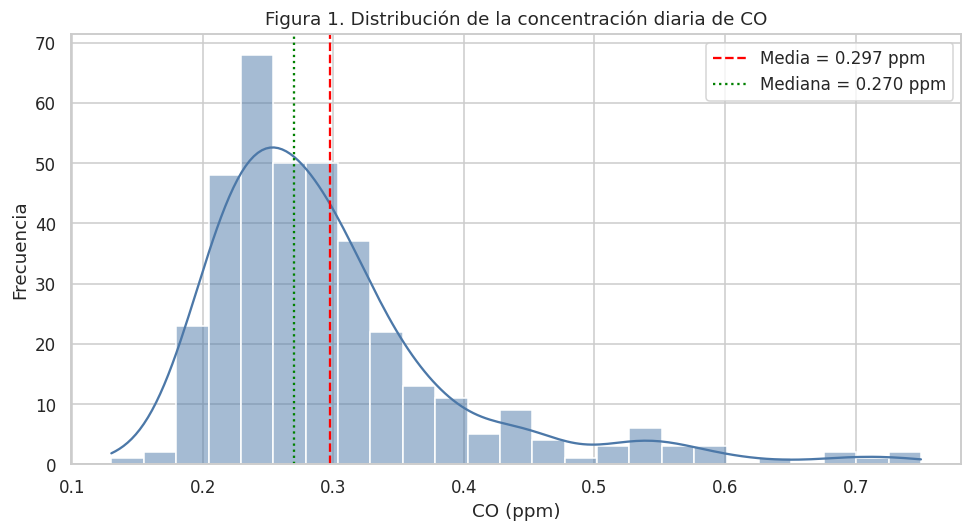

In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(serie["CO"], bins=25, kde=True, color="#4C78A8", edgecolor="white")
plt.axvline(serie["CO"].mean(), color="red", linestyle="--",
            label=f"Media = {serie['CO'].mean():.3f} ppm")
plt.axvline(serie["CO"].median(), color="green", linestyle=":",
            label=f"Mediana = {serie['CO'].median():.3f} ppm")
plt.title("Figura 1. Distribución de la concentración diaria de CO")
plt.xlabel("CO (ppm)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Evolución temporal y promedio móvil

La serie diaria conserva las fluctuaciones de cada fecha. El promedio móvil de siete días suaviza esas variaciones y facilita la identificación de periodos de aumento o disminución.

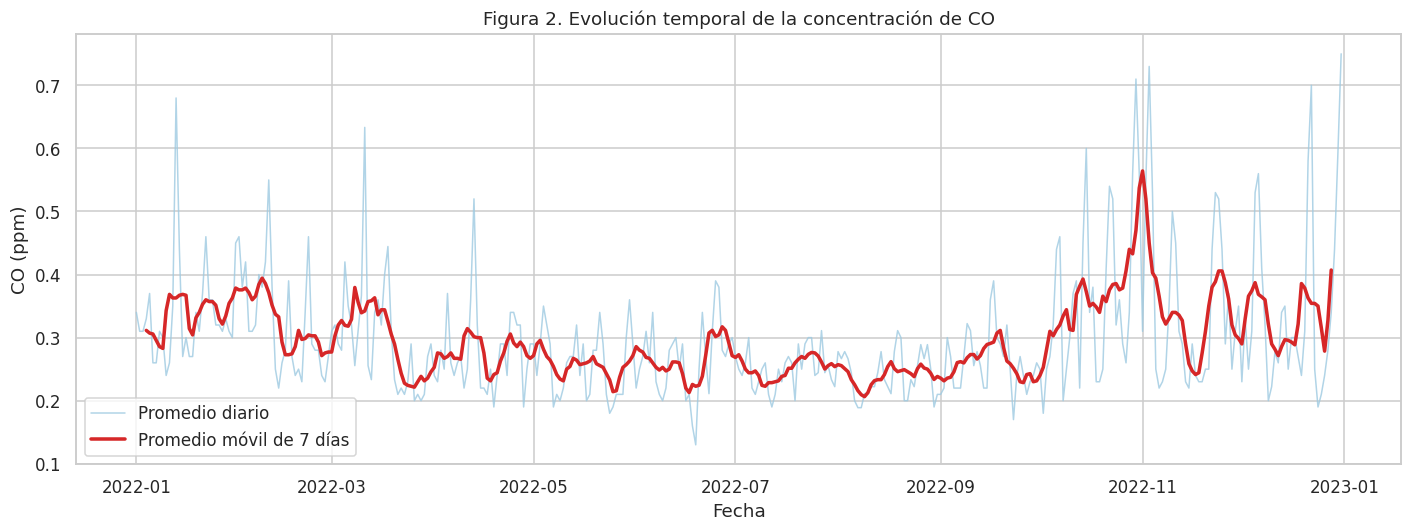

In [9]:
plt.figure(figsize=(13, 5))
plt.plot(serie["Fecha"], serie["CO"], color="#9ECAE1", linewidth=1,
         alpha=0.8, label="Promedio diario")
plt.plot(serie["Fecha"], serie["media_movil_7d"], color="#D62728",
         linewidth=2.3, label="Promedio móvil de 7 días")
plt.title("Figura 2. Evolución temporal de la concentración de CO")
plt.xlabel("Fecha")
plt.ylabel("CO (ppm)")
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Perfil mensual

Se compara el promedio mensual de CO. Las barras verticales representan la desviación estándar y muestran la variabilidad dentro de cada mes.

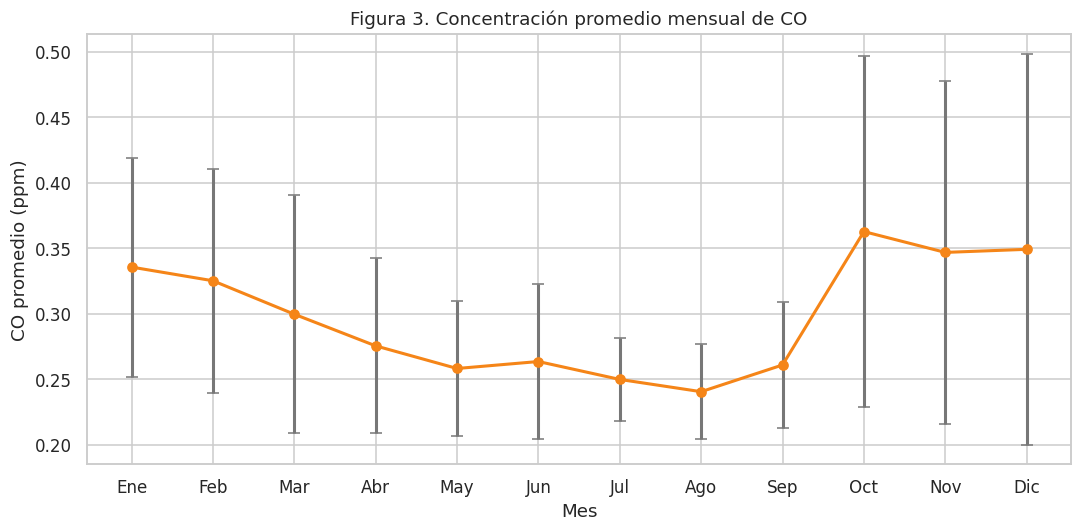

,mes,mean,std
0,1,0.3358,0.0835
1,2,0.3254,0.0854
2,3,0.2998,0.0910
3,4,0.2757,0.0667
4,5,0.2584,0.0518
5,6,0.2637,0.0592
6,7,0.2500,0.0314
7,8,0.2407,0.0360
8,9,0.2611,0.0480
9,10,0.3629,0.1337


In [10]:
mensual = serie.groupby("mes")["CO"].agg(["mean", "std"]).reset_index()
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

plt.figure(figsize=(10, 5))
plt.errorbar(mensual["mes"], mensual["mean"], yerr=mensual["std"],
             fmt="o-", color="#F58518", ecolor="#777777", capsize=4,
             linewidth=2, markersize=6)
plt.xticks(range(1, 13), meses)
plt.title("Figura 3. Concentración promedio mensual de CO")
plt.xlabel("Mes")
plt.ylabel("CO promedio (ppm)")
plt.tight_layout()
plt.show()

mensual.round(4)

### 4.4 Comparación espacial entre estaciones

El gráfico compara el promedio anual de cada estación. Esto permite reconocer zonas con concentraciones habitualmente mayores o menores.

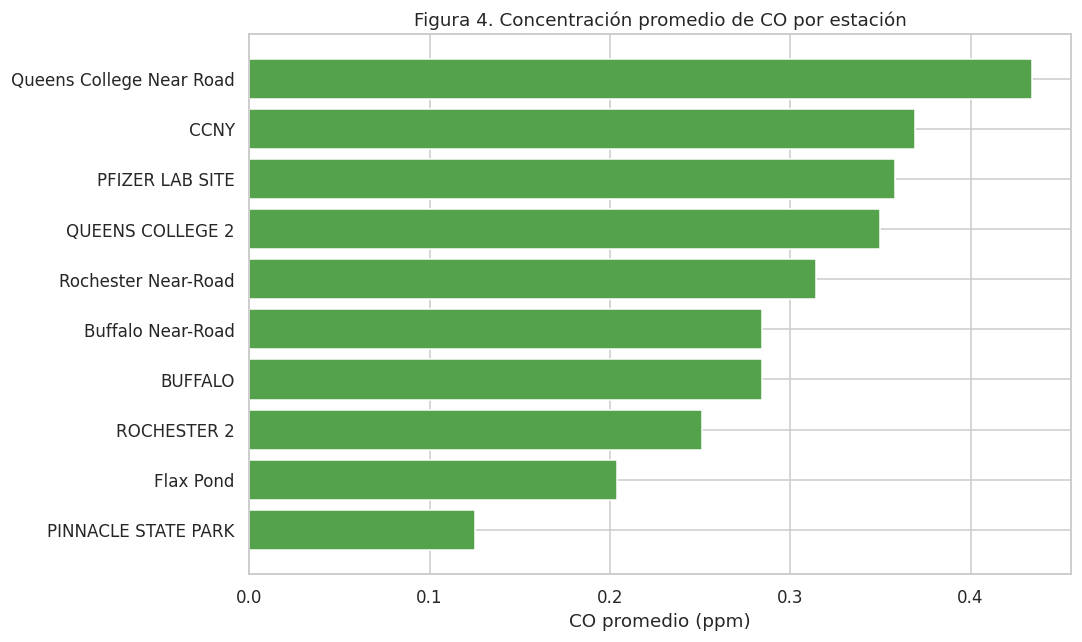

,Promedio,Maximo,Registros
Local Site Name,,,
PINNACLE STATE PARK,0.125,0.3,355
Flax Pond,0.204,0.4,365
ROCHESTER 2,0.251,0.7,365
BUFFALO,0.284,0.8,359
Buffalo Near-Road,0.284,0.8,352
Rochester Near-Road,0.314,0.6,341
QUEENS COLLEGE 2,0.350,1.3,365
PFIZER LAB SITE,0.358,1.7,365
CCNY,0.369,1.2,364


In [11]:
por_estacion = (
    df.groupby("Local Site Name")[CONC]
      .agg(Promedio="mean", Maximo="max", Registros="count")
      .sort_values("Promedio")
)

plt.figure(figsize=(10, 6))
plt.barh(por_estacion.index, por_estacion["Promedio"], color="#54A24B")
plt.title("Figura 4. Concentración promedio de CO por estación")
plt.xlabel("CO promedio (ppm)")
plt.ylabel("")
plt.tight_layout()
plt.show()

por_estacion.round(3)

### 4.5 Matriz de correlación

Antes de modelar se construyen los componentes estacionales y el rezago de un día. El mapa de calor resume la dirección e intensidad de las asociaciones lineales.

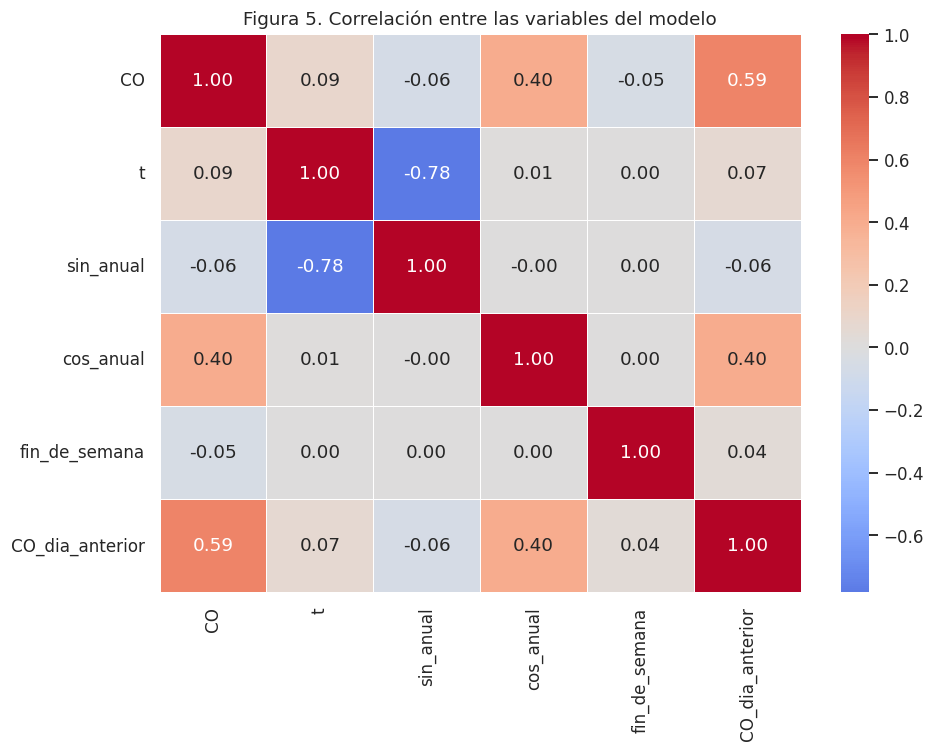

In [12]:
serie["sin_anual"] = np.sin(2 * np.pi * serie["dia_año"] / 365)
serie["cos_anual"] = np.cos(2 * np.pi * serie["dia_año"] / 365)
serie["CO_dia_anterior"] = serie["CO"].shift(1)

datos_modelo = serie.dropna(subset=["CO_dia_anterior"]).reset_index(drop=True)

variables_corr = [
    "CO", "t", "sin_anual", "cos_anual",
    "fin_de_semana", "CO_dia_anterior"
]

plt.figure(figsize=(9, 7))
sns.heatmap(datos_modelo[variables_corr].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Figura 5. Correlación entre las variables del modelo")
plt.tight_layout()
plt.show()

### 4.6 Persistencia de la concentración

La nube de puntos y la recta permiten evaluar si la concentración del día anterior se relaciona con la concentración del día actual.

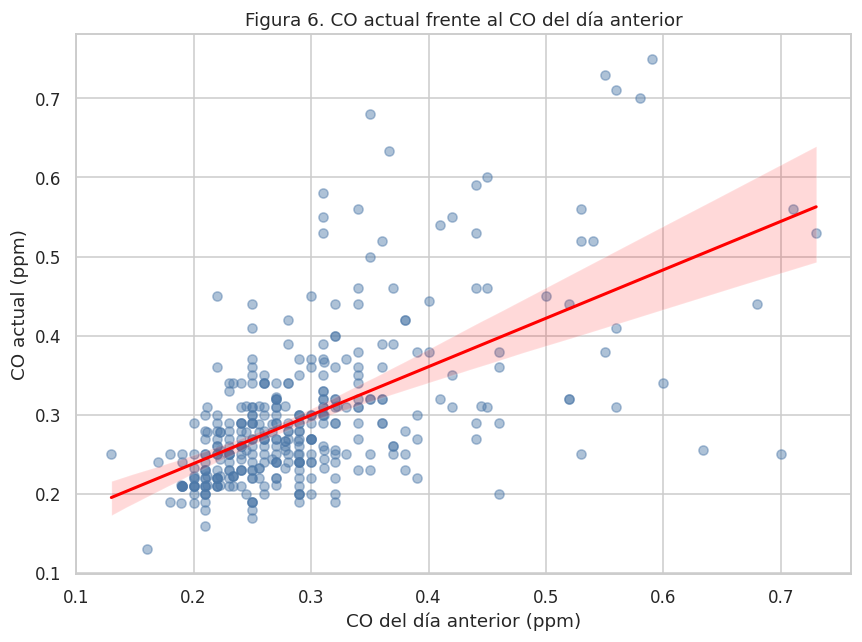

In [13]:
plt.figure(figsize=(8, 6))
sns.regplot(data=datos_modelo, x="CO_dia_anterior", y="CO",
            scatter_kws={"alpha": 0.45, "color": "#4C78A8"},
            line_kws={"color": "red", "linewidth": 2})
plt.title("Figura 6. CO actual frente al CO del día anterior")
plt.xlabel("CO del día anterior (ppm)")
plt.ylabel("CO actual (ppm)")
plt.tight_layout()
plt.show()

## 5. Modelo 1: regresión lineal simple

El primer modelo utiliza solamente el tiempo transcurrido:

\[
CO_t = eta_0 + eta_1 t + arepsilon_t
\]

Este modelo funciona como una referencia básica para determinar si existe una tendencia lineal general durante el año.

In [14]:
X_simple = datos_modelo[["t"]]
y = datos_modelo["CO"]

modelo_simple_total = LinearRegression().fit(X_simple, y)
pred_simple_total = modelo_simple_total.predict(X_simple)

print(f"Intercepto: {modelo_simple_total.intercept_:.6f}")
print(f"Pendiente diaria: {modelo_simple_total.coef_[0]:.8f} ppm/día")
print(f"R² del ajuste completo: {r2_score(y, pred_simple_total):.4f}")
print(f"RMSE del ajuste completo: {np.sqrt(mean_squared_error(y, pred_simple_total)):.4f} ppm")

Intercepto: 0.282201
Pendiente diaria: 0.00008247 ppm/día
R² del ajuste completo: 0.0079
RMSE del ajuste completo: 0.0971 ppm


## 6. Modelo 2: regresión lineal múltiple

El segundo modelo incorpora:

- `t`: tendencia general.
- `sin_anual` y `cos_anual`: estacionalidad anual.
- `fin_de_semana`: diferencia entre días hábiles y fines de semana.
- `CO_dia_anterior`: persistencia de la concentración.

No se utiliza el AQI como predictor porque es una transformación de la propia concentración de CO.

In [15]:
predictores = [
    "t",
    "sin_anual",
    "cos_anual",
    "fin_de_semana",
    "CO_dia_anterior"
]

X_multiple = datos_modelo[predictores]

# Ajuste exploratorio con toda la serie
modelo_multiple_total = LinearRegression().fit(X_multiple, y)
pred_multiple_total = modelo_multiple_total.predict(X_multiple)

coeficientes_totales = pd.DataFrame({
    "Variable": predictores,
    "Coeficiente": modelo_multiple_total.coef_
})

print(f"Intercepto: {modelo_multiple_total.intercept_:.6f}")
print(f"R² del ajuste completo: {r2_score(y, pred_multiple_total):.4f}")
print(f"RMSE del ajuste completo: {np.sqrt(mean_squared_error(y, pred_multiple_total)):.4f} ppm")
display(coeficientes_totales.round(6))

Intercepto: 0.133294
R² del ajuste completo: 0.3935
RMSE del ajuste completo: 0.0760 ppm


,Variable,Coeficiente
0,t,0.000063
1,sin_anual,0.002727
2,cos_anual,0.027290
3,fin_de_semana,-0.014850
4,CO_dia_anterior,0.529677


## 7. Validación temporal

La separación se realiza de manera cronológica:

- **Entrenamiento:** enero a septiembre de 2022.
- **Prueba:** octubre a diciembre de 2022.

No se realiza una división aleatoria porque se trabaja con una serie temporal y los datos futuros no deben utilizarse para entrenar un modelo que intenta predecirlos.

In [16]:
corte = datos_modelo["Fecha"] < "2022-10-01"

X_train_simple = datos_modelo.loc[corte, ["t"]]
X_test_simple = datos_modelo.loc[~corte, ["t"]]
X_train_multiple = datos_modelo.loc[corte, predictores]
X_test_multiple = datos_modelo.loc[~corte, predictores]
y_train = datos_modelo.loc[corte, "CO"]
y_test = datos_modelo.loc[~corte, "CO"]

modelo_simple = LinearRegression().fit(X_train_simple, y_train)
modelo_multiple = LinearRegression().fit(X_train_multiple, y_train)

pred_simple = modelo_simple.predict(X_test_simple)
pred_multiple = modelo_multiple.predict(X_test_multiple)

print("Días de entrenamiento:", len(y_train))
print("Días de prueba:", len(y_test))

Días de entrenamiento: 272
Días de prueba: 92


### 7.1 Métricas de evaluación

- **R²:** proporción de la variabilidad explicada por el modelo. Puede ser negativo en prueba si el modelo predice peor que la media.
- **RMSE:** magnitud típica del error, expresada en ppm y con mayor penalización para errores grandes.
- **MAE:** promedio de los errores absolutos, también expresado en ppm.

In [17]:
def metricas(nombre, real, predicho):
    return {
        "Modelo": nombre,
        "R²": r2_score(real, predicho),
        "RMSE (ppm)": np.sqrt(mean_squared_error(real, predicho)),
        "MAE (ppm)": mean_absolute_error(real, predicho)
    }

comparacion = pd.DataFrame([
    metricas("Regresión simple", y_test, pred_simple),
    metricas("Regresión múltiple", y_test, pred_multiple)
])

comparacion.round(4)

,Modelo,R²,RMSE (ppm),MAE (ppm)
0,Regresión simple,-1.0872,0.1967,0.1433
1,Regresión múltiple,0.0950,0.1295,0.0926


### 7.2 Coeficientes del modelo múltiple

El signo indica la dirección de la asociación manteniendo constantes las demás variables. Debido a que las variables tienen escalas distintas, el tamaño bruto de los coeficientes no debe interpretarse por sí solo como importancia.

In [18]:
tabla_coeficientes = pd.DataFrame({
    "Variable": predictores,
    "Coeficiente": modelo_multiple.coef_
})

tabla_coeficientes.loc[len(tabla_coeficientes)] = [
    "Intercepto", modelo_multiple.intercept_
]

tabla_coeficientes.round(6)

,Variable,Coeficiente
0,t,-0.000176
1,sin_anual,-0.007971
2,cos_anual,0.013742
3,fin_de_semana,-0.012134
4,CO_dia_anterior,0.416211
5,Intercepto,0.194523


## 8. Evaluación gráfica del modelo múltiple

### 8.1 Valores reales frente a predichos

La línea diagonal representa una predicción perfecta. Mientras más cerca se encuentren los puntos de esta línea, menores son los errores del modelo.

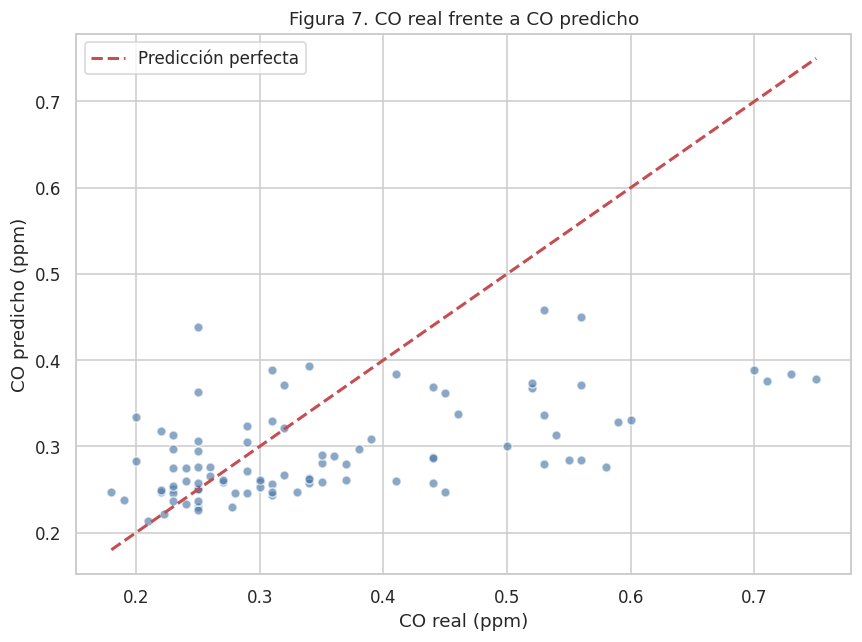

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_multiple, alpha=0.65, color="#4C78A8", edgecolor="white")
lim_inf = min(y_test.min(), pred_multiple.min())
lim_sup = max(y_test.max(), pred_multiple.max())
plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], "r--", linewidth=2,
         label="Predicción perfecta")
plt.title("Figura 7. CO real frente a CO predicho")
plt.xlabel("CO real (ppm)")
plt.ylabel("CO predicho (ppm)")
plt.legend()
plt.tight_layout()
plt.show()

### 8.2 Comparación temporal en el conjunto de prueba

Este gráfico permite observar en qué fechas el modelo sigue correctamente los aumentos y descensos del CO.

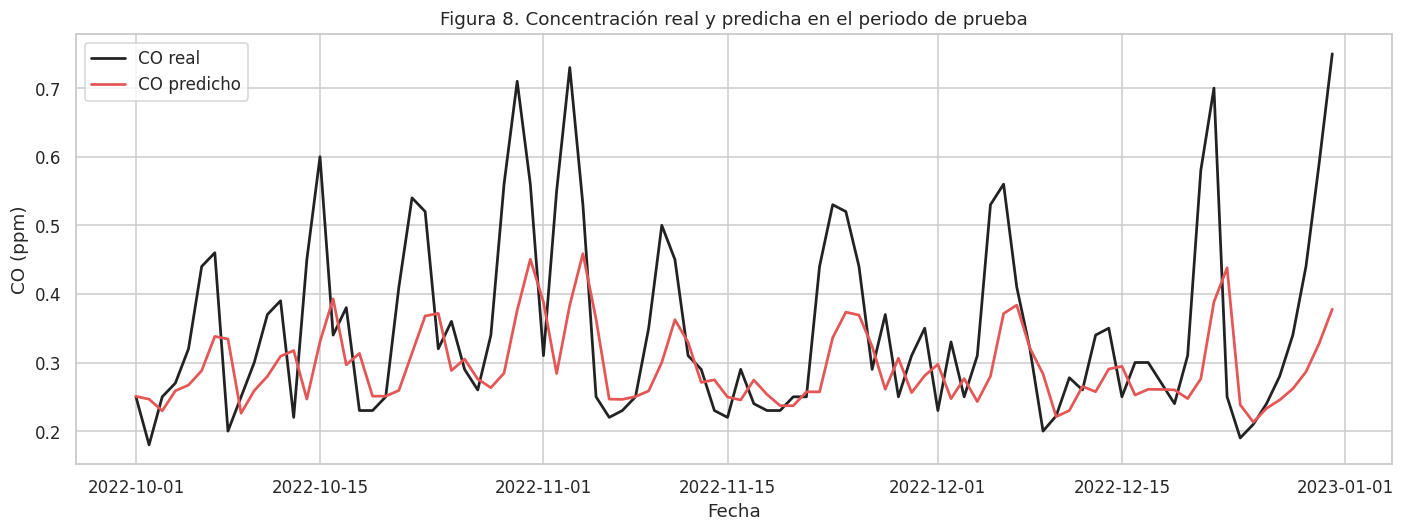

In [20]:
fechas_test = datos_modelo.loc[~corte, "Fecha"]

plt.figure(figsize=(13, 5))
plt.plot(fechas_test, y_test, color="#222222", linewidth=1.8, label="CO real")
plt.plot(fechas_test, pred_multiple, color="#E45756", linewidth=1.8,
         label="CO predicho")
plt.title("Figura 8. Concentración real y predicha en el periodo de prueba")
plt.xlabel("Fecha")
plt.ylabel("CO (ppm)")
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 Distribución de los residuos

Los residuos son las diferencias entre los valores reales y los predichos. Una distribución centrada alrededor de cero indica ausencia de un sesgo general pronunciado.

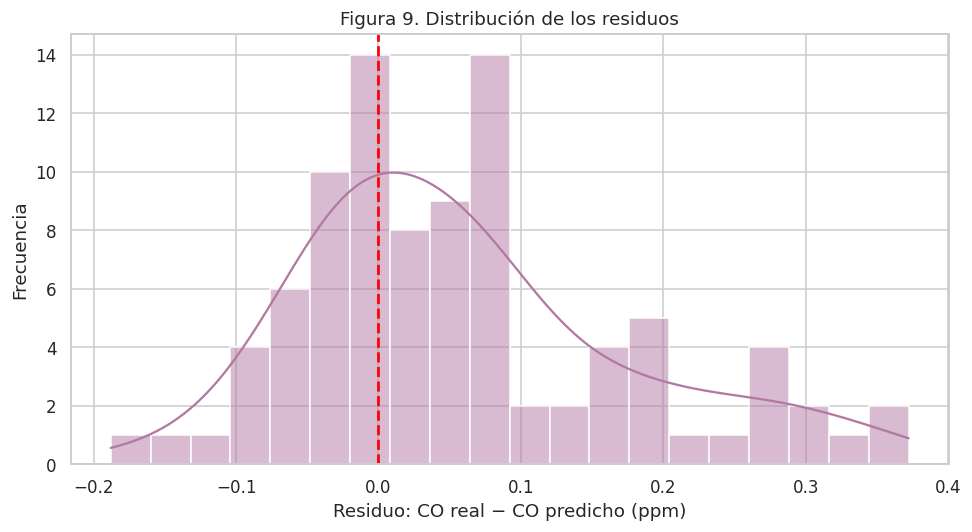

In [21]:
residuos = y_test.to_numpy() - pred_multiple

plt.figure(figsize=(9, 5))
sns.histplot(residuos, bins=20, kde=True, color="#B279A2", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1.8)
plt.title("Figura 9. Distribución de los residuos")
plt.xlabel("Residuo: CO real − CO predicho (ppm)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### 8.4 Residuos frente a valores predichos

Los residuos deberían distribuirse alrededor de cero sin formar un patrón evidente. Una forma curva o un aumento progresivo de la dispersión sugeriría que el modelo lineal no captura completamente la relación.

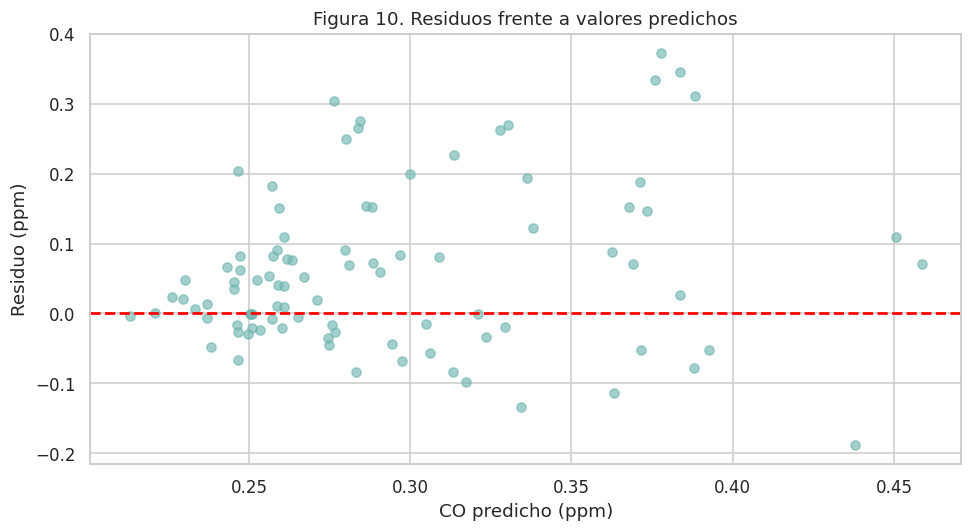

In [22]:
plt.figure(figsize=(9, 5))
plt.scatter(pred_multiple, residuos, alpha=0.65, color="#72B7B2")
plt.axhline(0, color="red", linestyle="--", linewidth=1.8)
plt.title("Figura 10. Residuos frente a valores predichos")
plt.xlabel("CO predicho (ppm)")
plt.ylabel("Residuo (ppm)")
plt.tight_layout()
plt.show()

## 9. Resultados automáticos para la conclusión

La siguiente celda resume los valores principales obtenidos. Estos resultados deben utilizarse para redactar la interpretación final sin inventar cifras.

In [23]:
mejor_fila = comparacion.loc[comparacion["RMSE (ppm)"].idxmin()]
coef_lag = tabla_coeficientes.loc[
    tabla_coeficientes["Variable"] == "CO_dia_anterior", "Coeficiente"
].iloc[0]

print(f"CO promedio diario: {serie['CO'].mean():.4f} ppm")
print(f"CO máximo de la serie diaria: {serie['CO'].max():.4f} ppm")
print(f"Mejor modelo según RMSE: {mejor_fila['Modelo']}")
print(f"R² de prueba del mejor modelo: {mejor_fila['R²']:.4f}")
print(f"RMSE de prueba del mejor modelo: {mejor_fila['RMSE (ppm)']:.4f} ppm")
print(f"MAE de prueba del mejor modelo: {mejor_fila['MAE (ppm)']:.4f} ppm")
print(f"Coeficiente del CO del día anterior: {coef_lag:.4f}")

CO promedio diario: 0.2974 ppm
CO máximo de la serie diaria: 0.7500 ppm
Mejor modelo según RMSE: Regresión múltiple
R² de prueba del mejor modelo: 0.0950
RMSE de prueba del mejor modelo: 0.1295 ppm
MAE de prueba del mejor modelo: 0.0926 ppm
Coeficiente del CO del día anterior: 0.4162


## 10. Conclusiones

Después de ejecutar todas las celdas, redacta las conclusiones utilizando los resultados impresos en la sección anterior. Puedes seguir esta estructura:

1. Indicar el promedio y el máximo diario de CO encontrados.
2. Describir el patrón temporal o mensual observado en los gráficos.
3. Comparar el desempeño de la regresión simple y la múltiple mediante R², RMSE y MAE.
4. Explicar si la concentración del día anterior ayuda a estimar la concentración actual.
5. Mencionar las limitaciones: solo se analiza un año, se promedian estaciones diferentes y no se incluyen variables meteorológicas o de tráfico.

> **Nota metodológica:** un buen ajuste describe asociaciones presentes en los datos, pero no demuestra causalidad. Para mejorar el modelo sería conveniente incorporar temperatura, velocidad del viento, precipitación y volumen de tráfico.